# 2026 Australian Grand Prix — Race Debrief

**Date:** March 8, 2026 \
**Circuit:** Melbourne Grand Prix Circuit \
**Winner:** George Russell \
**Team:** Mercedes

New regulations, new season, anything goes.

## How Did Mercedes Overturn Ferrari's Early Lead?

The 2026 Australian Grand Prix opened a new season featuring a completely new set of regulations, meaning there was no established baseline to follow. Anything can happen, and this race was no exception. Ferrari qualified strongly with Leclerc taking pole position and Hamilton starting P3, demonstrating competitive pace throughout the qualifying session for the Ferraris. Although the Ferraris held P1 and P2 for the first half of the race, they ultimately finished behind both Mercedes by the checkered flag.

In [1]:
import fastf1 as ff1
import numpy as np
import pandas as pd
import timple.timedelta as tmpldelta
from fastf1 import plotting
from matplotlib import pyplot as plt
from matplotlib import ticker
import logging
logging.getLogger("fastf1").setLevel(logging.CRITICAL)

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

ff1.Cache.enable_cache("/Users/hai/fastf1_cache/")

# Setup matplotlib timedelta support
ff1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="none")

session = ff1.get_session(2026, 1, "R")
session.load()

results = session.results
laps = session.laps
drivers = session.drivers
drivers = [session.get_driver(driver)["Abbreviation"] for driver in drivers]

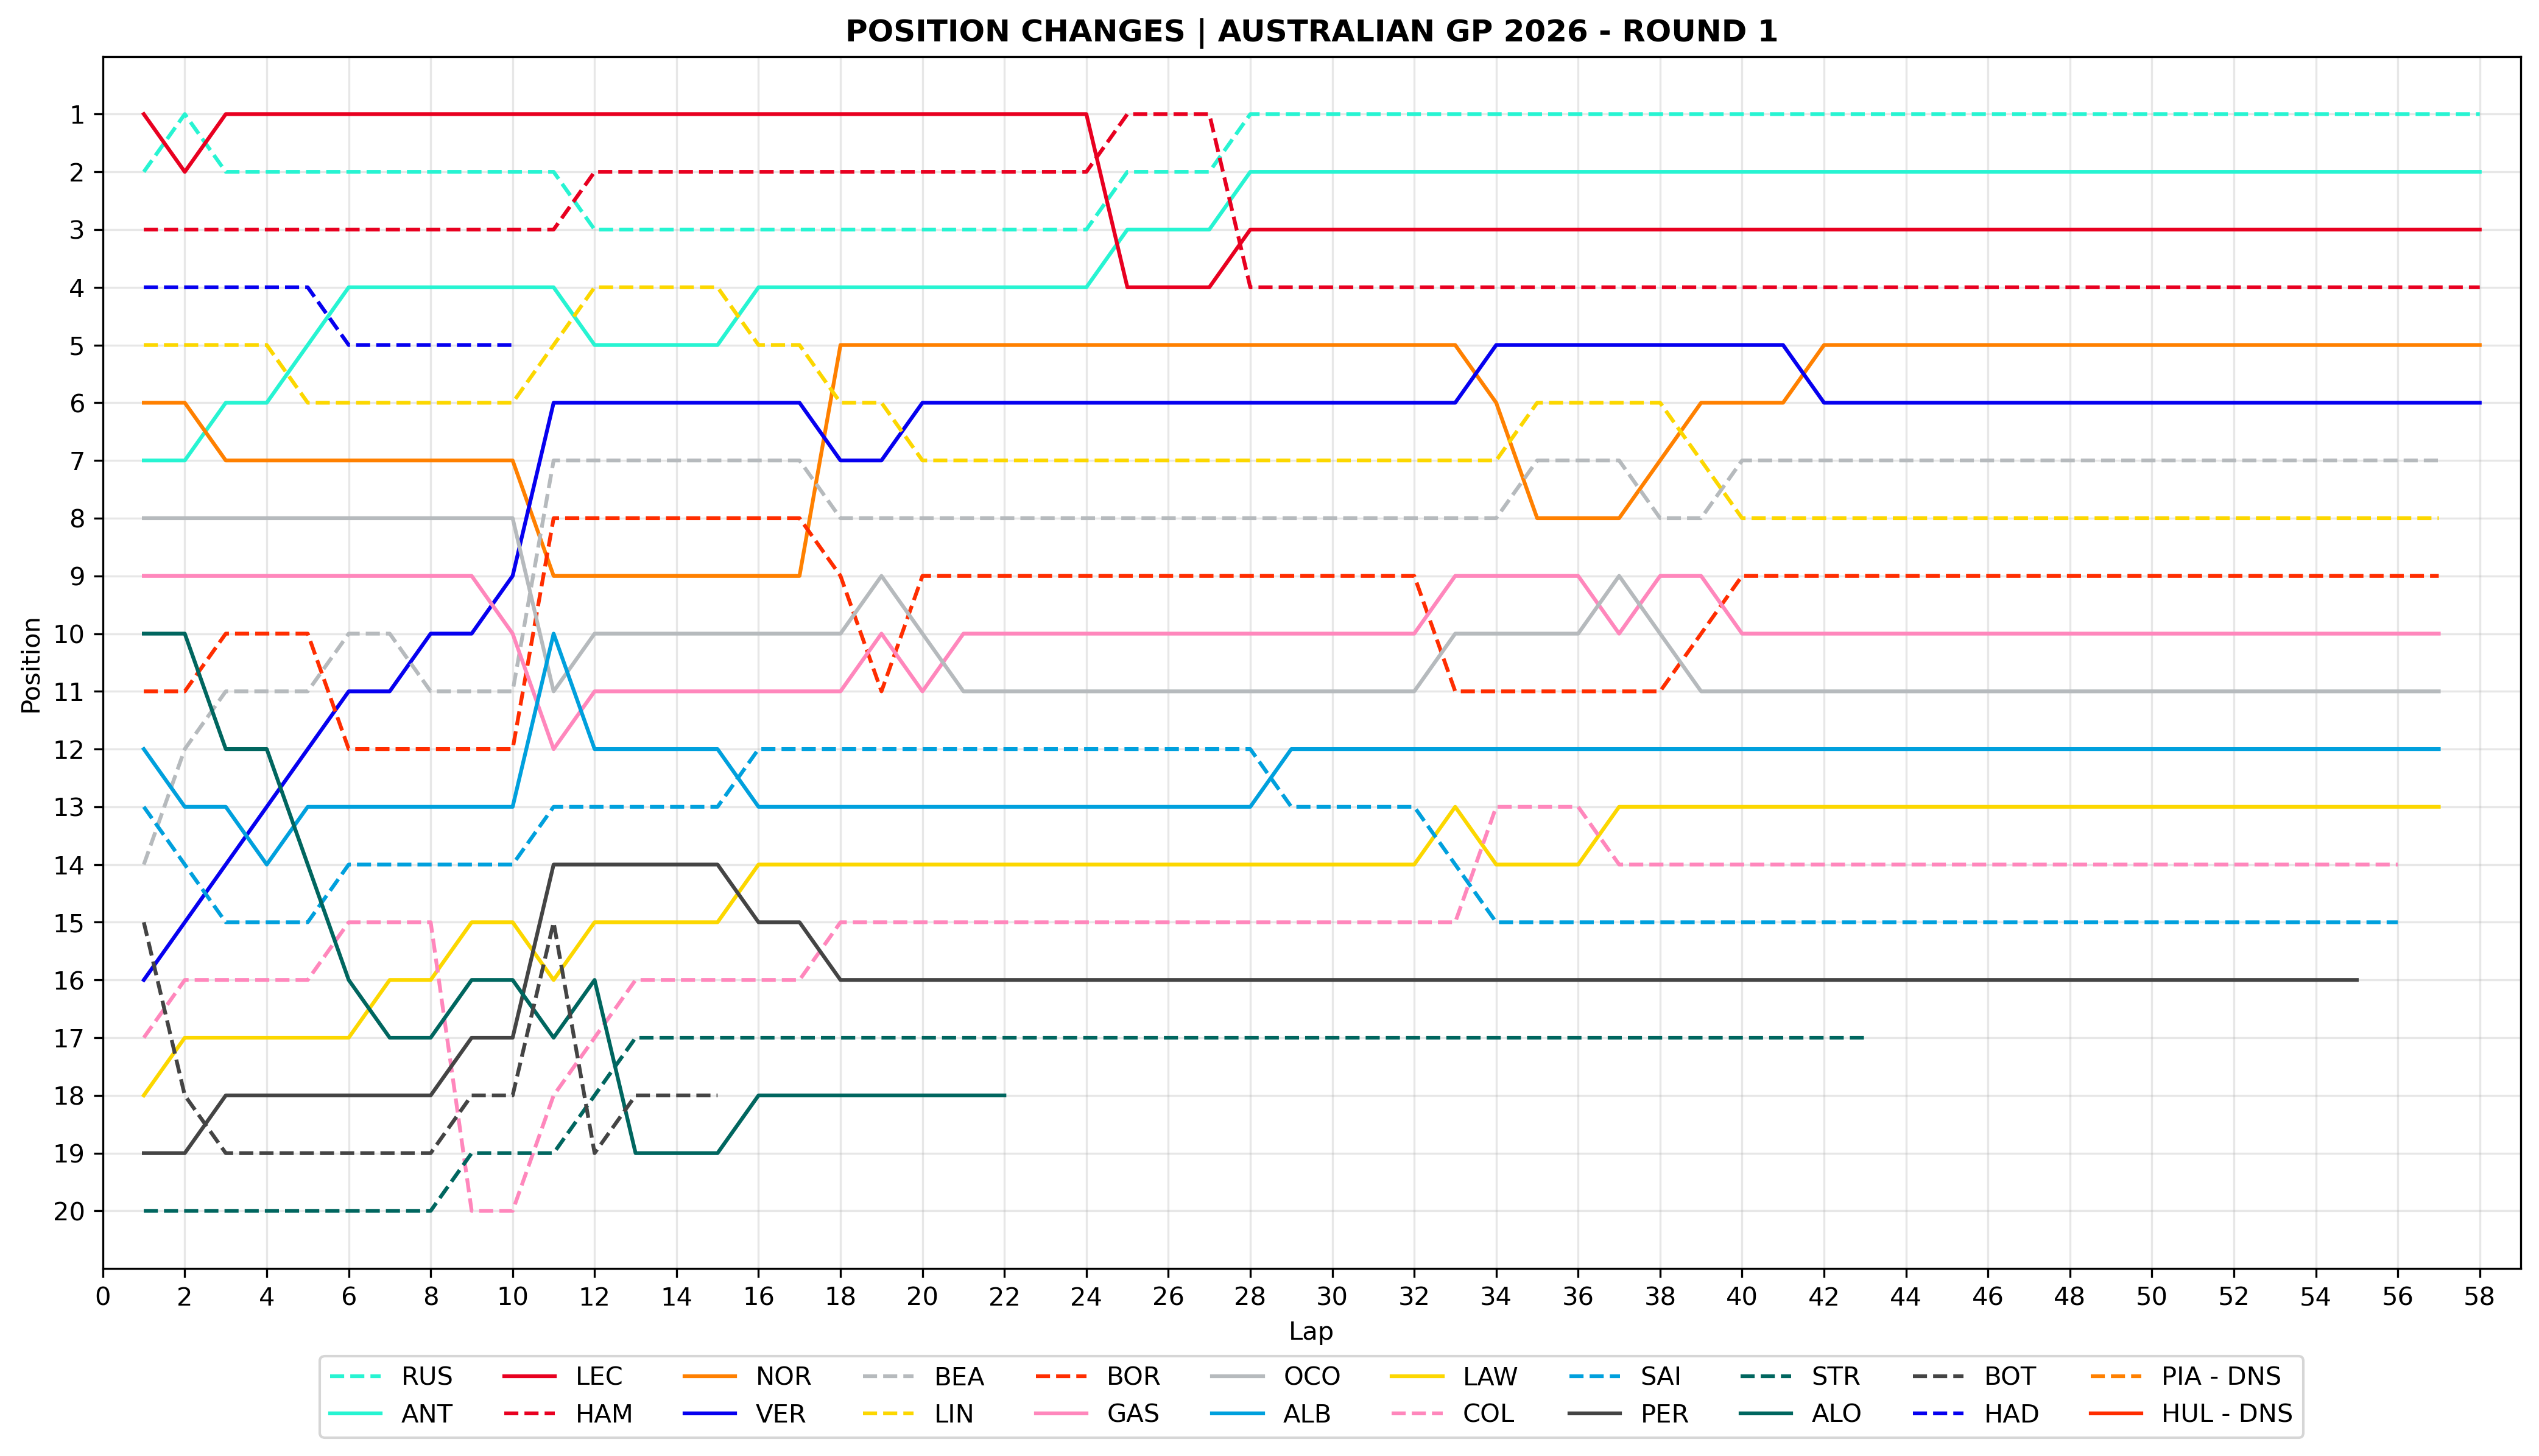

In [2]:
fig, ax = plt.subplots(figsize=(14, 8))

for driver in drivers:
    driver_laps = laps.pick_drivers(driver)
    style = ff1.plotting.get_driver_style(
        identifier=driver, style=["color", "linestyle"], session=session
    )

    if driver_laps.empty:
        ax.plot(
            driver_laps["LapNumber"],
            driver_laps["Position"],
            label=driver + " - DNS",
            **style
        )
        continue

    ax.plot(driver_laps["LapNumber"], driver_laps["Position"], label=driver, **style)

ax.set_xlabel("Lap")
ax.set_ylabel("Position")
ax.set_title(
    "Position Changes | Australian GP 2026 - Round 1".upper(), fontweight="bold"
)

# Change axis formatting
ax.set_xlim([0, max(laps["LapNumber"]) + 1])
ax.set_ylim([max(laps["Position"]) + 1, 0])
plt.xticks(np.arange(0, max(laps["LapNumber"]) + 1, 2))
plt.yticks(np.arange(1, max(laps["Position"]) + 1, 1))

plt.grid(alpha=0.3)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=11)
plt.tight_layout()
plt.show()

### Findings

Hamilton gained a position early in the race, around lap 11-12, which gave the Ferraris P1 and P2. Mid-race, Mercedes flipped the Ferrari advantage, taking P1 and P2, with Antonelli gaining five positions from P7 to P2. Were the Ferraris out-strategized? Out-paced? Did the Ferraris suffer higher tire degradation?

## Did Ferrari Lose to Mercedes in Raw Pace? Strategy? Tire management?

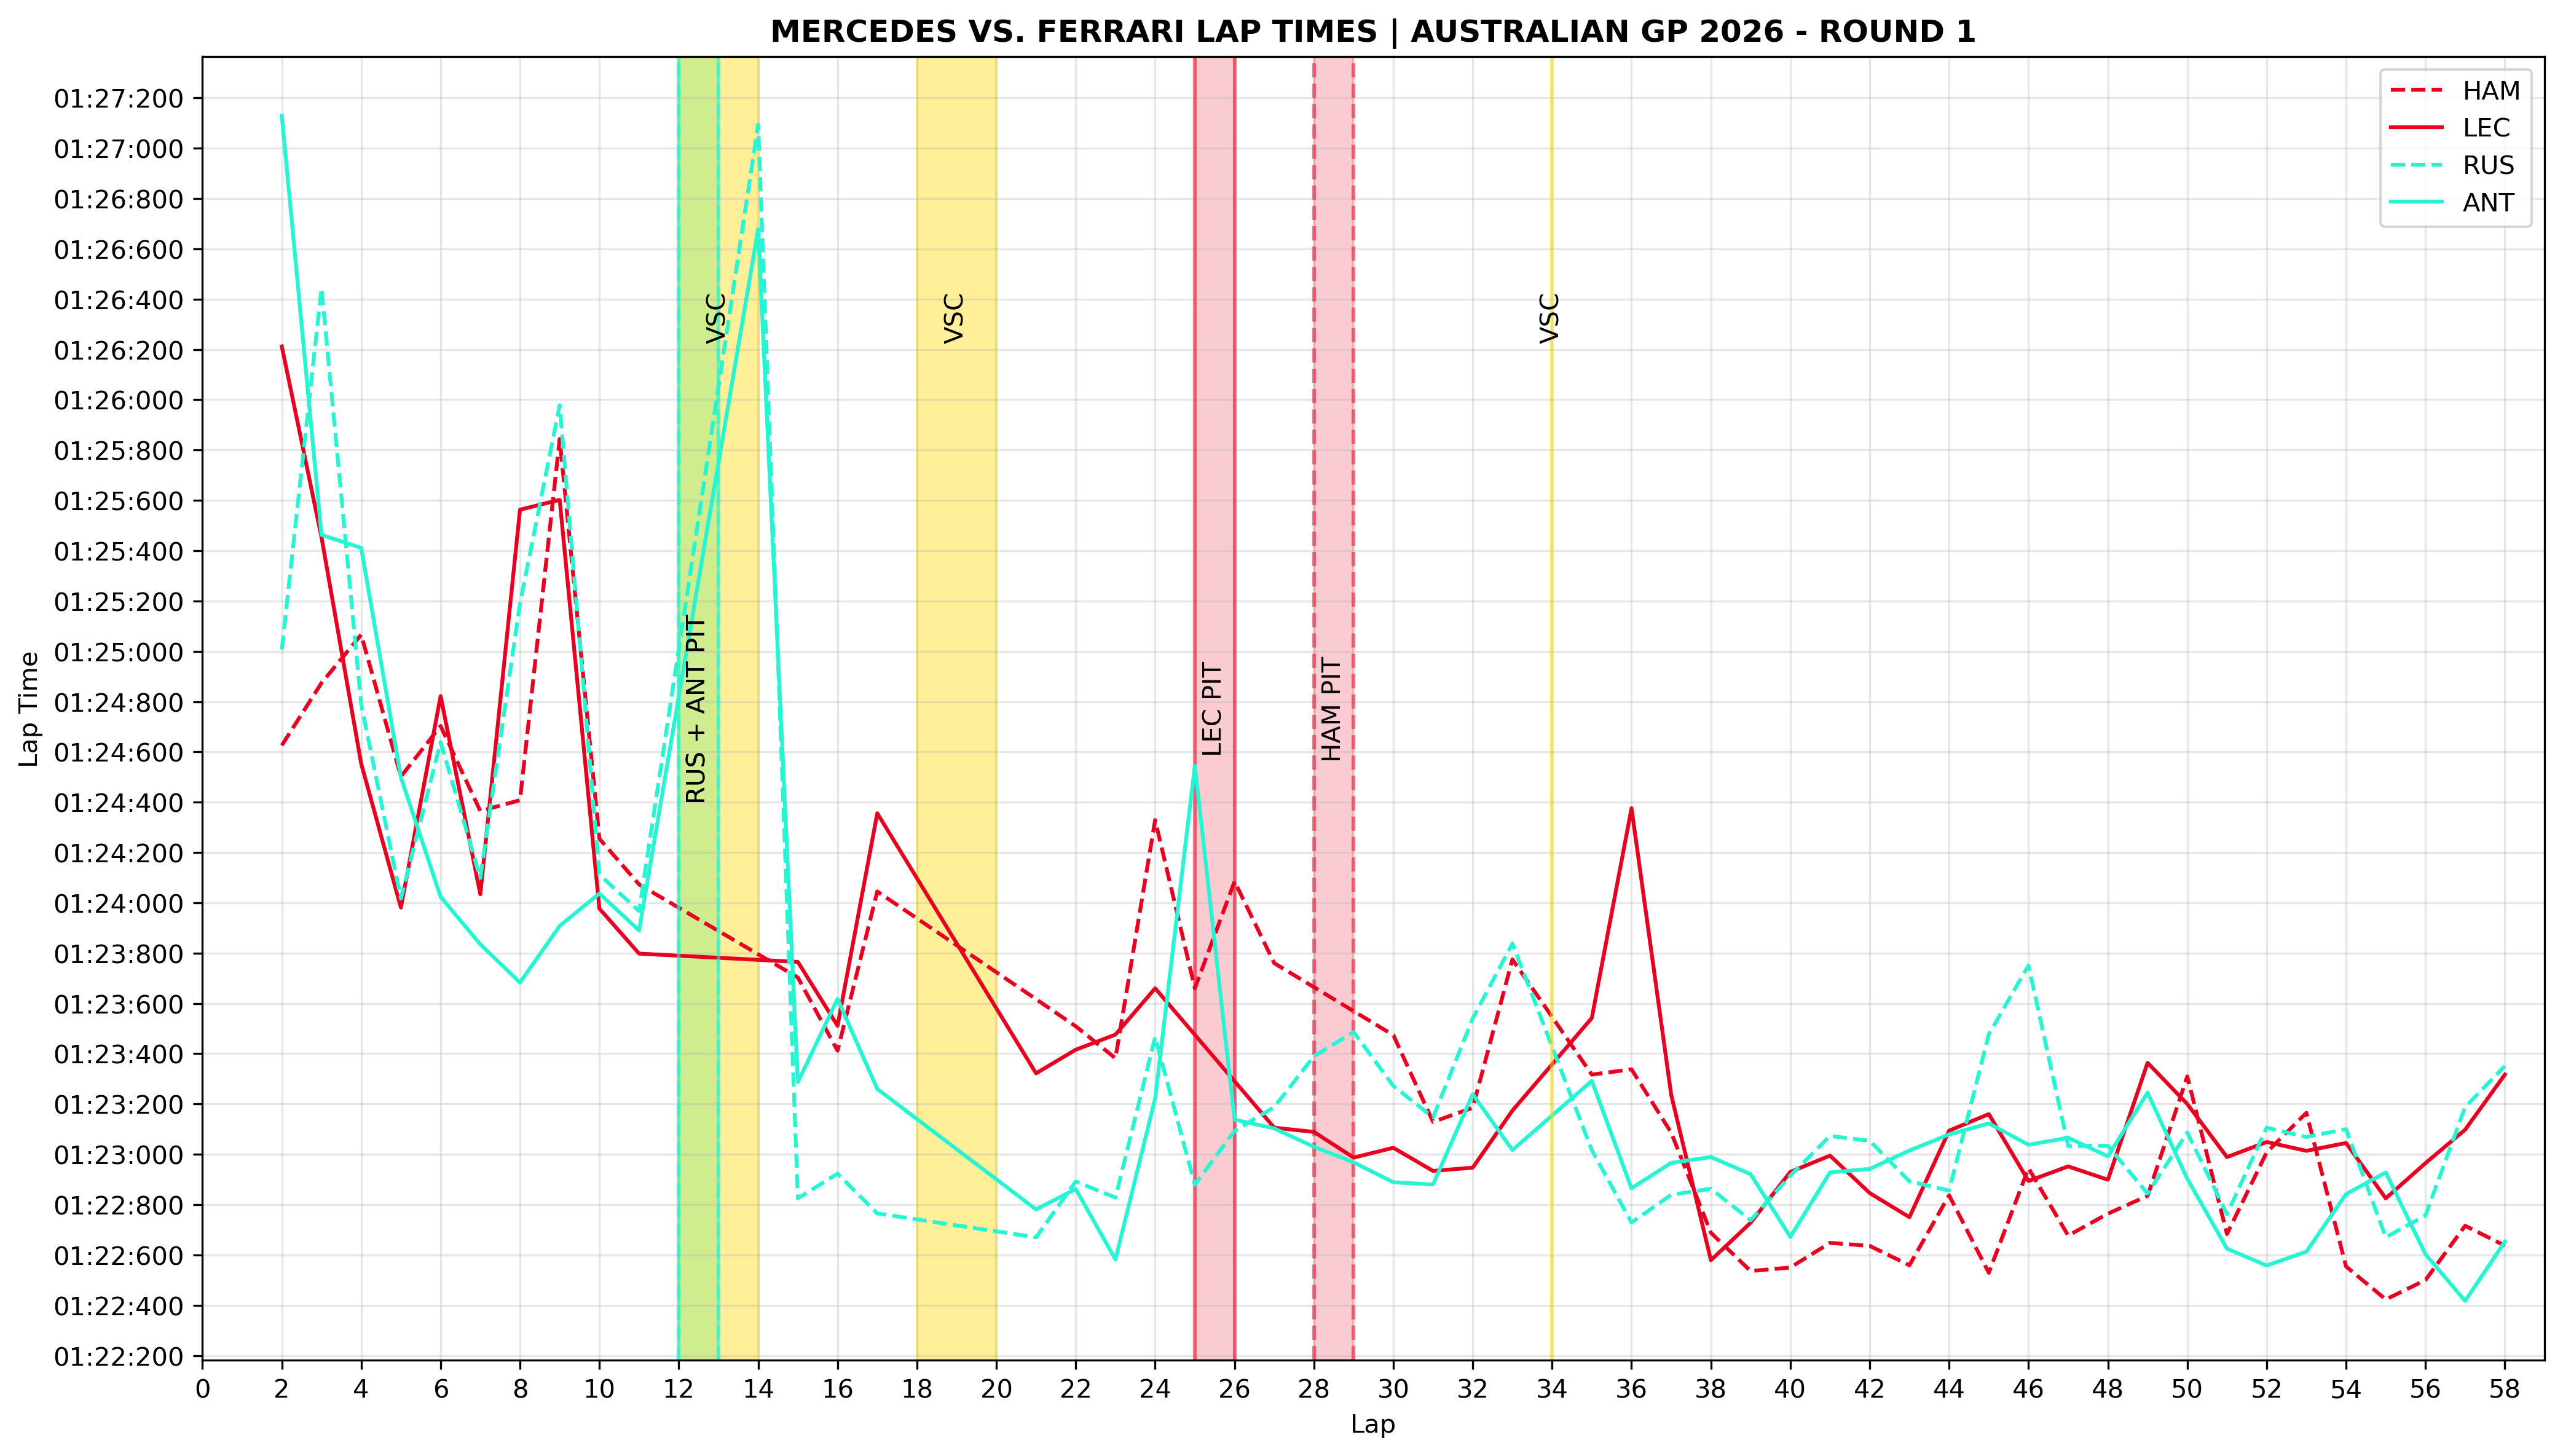

In [60]:
fig, ax = plt.subplots(figsize=(14, 8))

for driver in ("HAM", "LEC", "RUS", "ANT"):
    driver_laps = laps.pick_drivers(driver).pick_quicklaps().reset_index()

    # Lap Times
    style = ff1.plotting.get_driver_style(
        identifier=driver, style=["color", "linestyle"], session=session
    )
    ax.plot(driver_laps["LapNumber"], driver_laps["LapTime"], label=driver, **style)

    # Pit stops
    driver_laps = laps.pick_drivers(driver)
    driver_pit_laps = driver_laps.pick_box_laps()
    pit_style = ff1.plotting.get_driver_style(
        identifier=driver, style=["color", "linestyle"], session=session
    )

    # Highlight pit stop laps
    iterator = iter(driver_pit_laps["LapNumber"])
    for pit_in, pit_out in zip(iterator, iterator):
        plt.axvspan(
            pit_in,
            pit_out,
            color=pit_style["color"],
            alpha=0.2,
        )
        # Plot pit stop border
        for pit in [pit_in, pit_out]:
            plt.axvline(x=pit, ymin=0, ymax=1, **pit_style, alpha=0.5)

        if driver not in ["RUS", "ANT"]:
            plt.text(
                np.mean(driver_pit_laps["LapNumber"]),
                0.5,
                f"{driver} PIT",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                ha="center",
                va="center",
            )
        else:
            plt.text(
                np.mean(driver_pit_laps["LapNumber"]),
                0.5,
                f"RUS + ANT PIT",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                ha="center",
                va="center",
            )

# Virtual Safety Car
vsc_laps = laps.pick_drivers('RUS').pick_track_status(status='67', how='any')

i = 0
while i < len(vsc_laps) - 1:
    current_track_status = str(vsc_laps["TrackStatus"].iloc[i])

    # Condition for when vsc starts ('6')
    if "6" in current_track_status:
        current_lap = int(vsc_laps["LapNumber"].iloc[i])

        j = i
        while j < len(vsc_laps) - 1:
            next_track_status = str(vsc_laps["TrackStatus"].iloc[j])
            next_lap = int(vsc_laps["LapNumber"].iloc[j])

            # vsc ending ('7') and track clears ('1')
            if "71" in next_track_status:
                plt.axvspan(
                    current_lap,
                    next_lap,
                    color="gold",
                    alpha=0.4,
                )
                plt.text(
                    np.mean([current_lap, next_lap]),
                    0.8,
                    f"VSC",
                    transform=ax.get_xaxis_transform(),
                    rotation=90,
                    ha="center",
                    va="center",
                )
                i = j
                break
            j += 1
    i += 1

    # Condition when vsc starts and end within same lap
    if "6" in current_track_status and i == len(vsc_laps) - 1:
        current_lap = int(vsc_laps["LapNumber"].iloc[i])
        plt.axvline(x=current_lap, ymin=0, ymax=1, color="gold", alpha=0.5)
        plt.text(
            current_lap,
            0.8,
            f"VSC",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            ha="center",
            va="center",
        )

ax.set_xlabel("Lap")
ax.set_ylabel("Lap Time")
ax.set_title(
    "Mercedes vs. Ferrari Lap Times | Australian GP 2026 - Round 1".upper(),
    fontweight="bold",
)

# Change axis formatting and intervals
locator = tmpldelta.FixedTimedeltaLocator(base_unit="microseconds", interval=200000)
formatter = tmpldelta.TimedeltaFormatter("%m:%s:%ms")
ax.yaxis.set_major_locator(locator)
ax.yaxis.set_major_formatter(formatter)
ax.set_xlim([0, max(laps["LapNumber"]) + 1])
plt.xticks(np.arange(0, max(laps["LapNumber"]) + 1, 2))

ax.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
fp2 = ff1.get_session(2026, 1, 'FP2')
fp2.load()
fp2_laps = fp2.laps
merc_ferr_fp2_laps = fp2_laps.pick_teams(['Mercedes', "Ferrari"])
merc_ferr_fp2_medium_laps = merc_ferr_fp2_laps.pick_compounds('MEDIUM')

### Findings
When Isack Hadjar suffered a mechanical failure around lap 11-12, which forced the Virtual Safety Car (VSC) to deploy early, pressuring teams to decide whether to fully commit to the one stop under VSC for a cheap stop or keep track positions and pit later. Committing to a one-stop at this point of the race meant maintaining the hard tires for nearly 45 laps or taking a two-stop. Both Mercedes and Ferrari decided on two contrasting strategies. Mercedes decided to take advantage of the VSC and double-stack both drivers, while Ferrari decided to hold their track positions and pit later. Neither team ran medium long runs in FP2, meaning both went into the race with limited data on medium degradation. The decision to pit early becomes less of a pure data-driven strategy decision and becomes a risk-tolerance decision, where Mercedes chose to take the early risk and hope the dividends would pay out later, whereas Ferrari chose to play it safe.

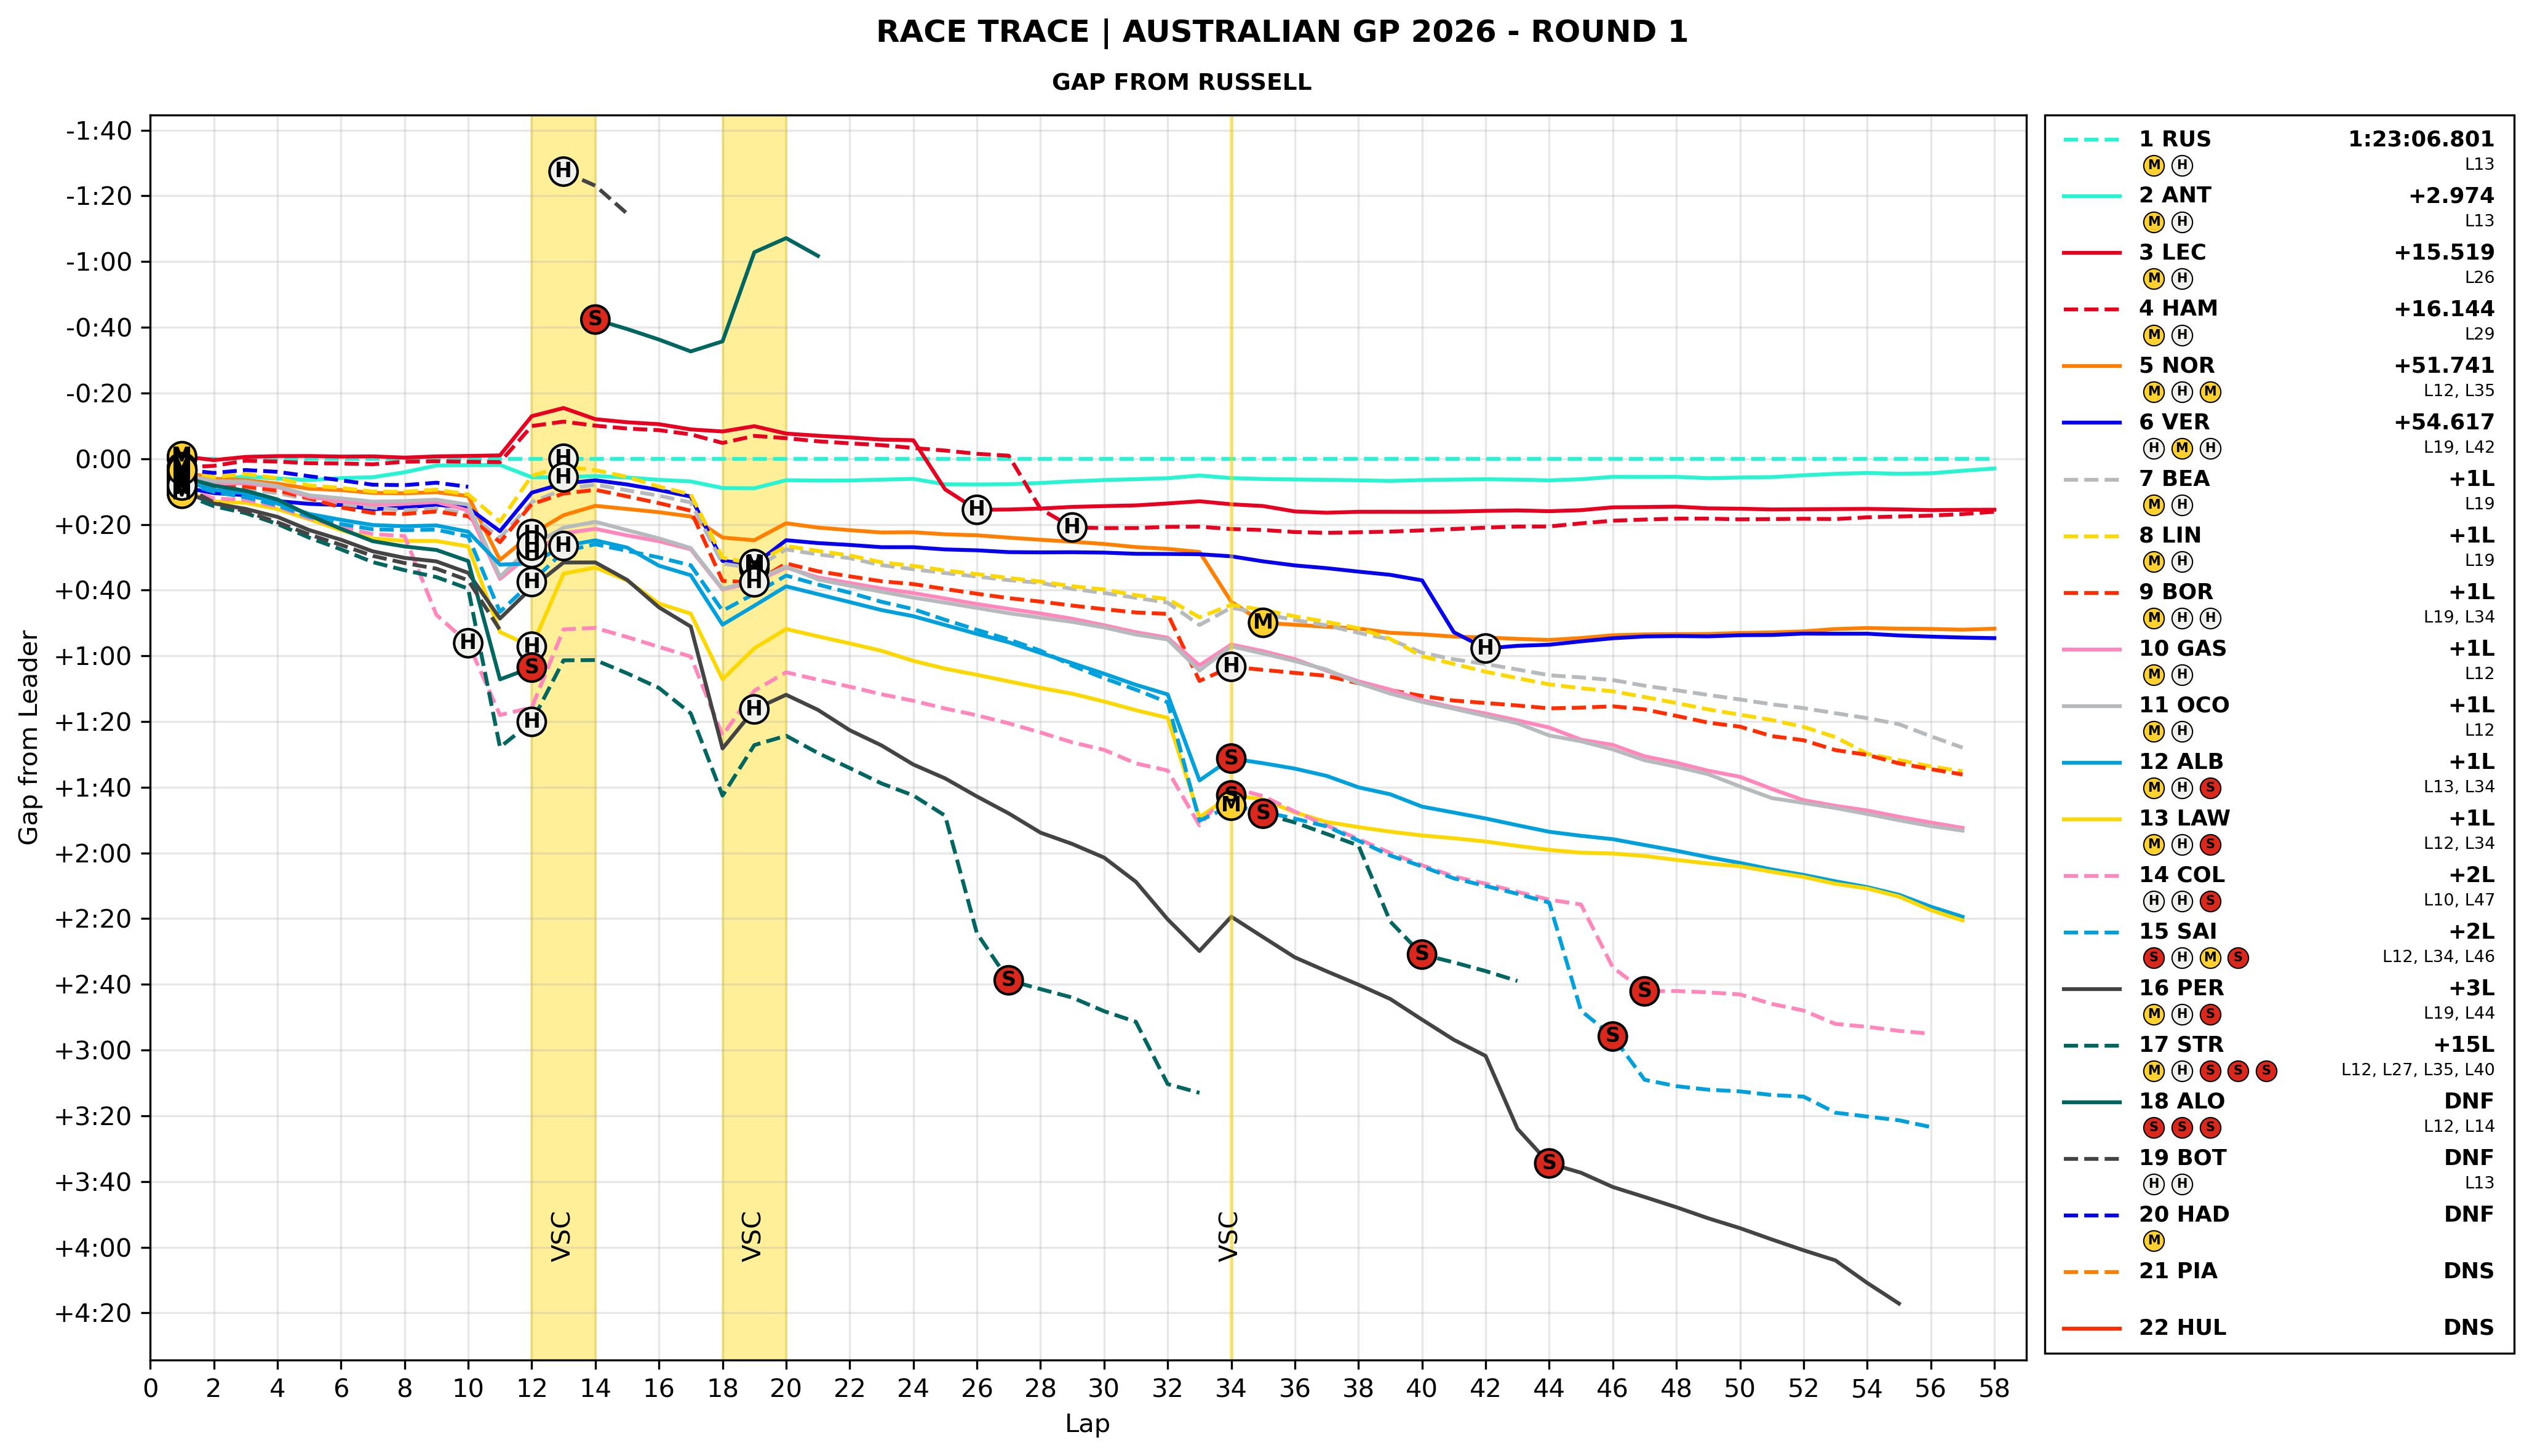

In [61]:
from datetime import timedelta

import fastf1.plotting
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch

# Convert LapTime to seconds
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()

# Group by driver and calculate cumulative sum lap by lap
laps["CumulativeLapTime"] = laps.groupby("Driver")["LapTimeSeconds"].cumsum()

# Define race winner for lap to lap gap-to-leader
race_winner = "RUS"
race_winner_laps = laps.pick_drivers(race_winner).reset_index()

# Driver stints
stints = laps[["Driver", "Stint", "Compound", "LapNumber", "CumulativeLapTime"]]
stints = stints.drop_duplicates(subset=["Driver", "Stint"])

fig, ax = plt.subplots(figsize=(14, 8))

stint_info = {}
legend_entries = []
for pos, driver in enumerate(drivers):
    driver_laps = laps.pick_drivers(driver).reset_index()
    driver_stints = stints[stints["Driver"] == driver].copy()
    stint_info[driver] = driver_stints[["Compound", "LapNumber"]].values.tolist()

    style = ff1.plotting.get_driver_style(
        identifier=driver, style=["color", "linestyle"], session=session
    )
    # Calculate the gap to the leader
    gap = driver_laps["CumulativeLapTime"] - race_winner_laps["CumulativeLapTime"]

    # Conditions for legend
    if results["Status"].iloc[pos] == "Retired":
        finish_gap_td = "DNF"

    elif results["Status"].iloc[pos] == "Did not start":
        finish_gap_td = "DNS"

    elif results["Status"].iloc[pos] == "Lapped":
        lapped = len(race_winner_laps) - results["Laps"].iloc[pos]
        finish_gap_td = f"+{int(lapped)}L"

    else:
        td = results["Time"].iloc[pos]
        finish_gap_td = (
            str(timedelta(seconds=td.total_seconds())).rstrip("0")
            if driver == race_winner
            else f'+{str(timedelta(seconds=td.total_seconds())).rstrip("0").lstrip("0:")}'
        )

    # Plotting tire markers
    compound_mapping = ff1.plotting.get_compound_mapping(session)
    driver_stints = stints[stints["Driver"] == driver]
    stint_lap_numbers = driver_stints["LapNumber"].values
    winner_cum_at_stints = race_winner_laps.set_index("LapNumber")["CumulativeLapTime"]
    stint_gap = (
        driver_stints["CumulativeLapTime"].values
        - winner_cum_at_stints.reindex(stint_lap_numbers).values
    )
    data_df = pd.DataFrame(
        {
            "LapNumber": stint_lap_numbers,
            "Gap": stint_gap,
            "Compound": driver_stints["Compound"].values,
        }
    )
    data_df["Color"] = data_df["Compound"].map(compound_mapping)

    # Tire marker shape + color
    ax.scatter(
        x="LapNumber",
        y="Gap",
        c="Color",
        data=data_df,
        zorder=5,
        edgecolors="black",
        s=120,
    )

    # Tire marker letter
    for _, row in data_df.iterrows():
        ax.text(
            row["LapNumber"],
            row["Gap"],
            row["Compound"][0],
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.plot(race_winner_laps["LapNumber"], gap, **style)
    legend_entries.append((style, f"{pos+1} {driver}", finish_gap_td))

# Laps VSC appeared
vsc_laps = laps.pick_drivers('RUS').pick_track_status(status='67', how='any')

i = 0
while i < len(vsc_laps) - 1:
    current_track_status = str(vsc_laps["TrackStatus"].iloc[i])

    # Condition for when vsc starts ('6')
    if "6" in current_track_status:
        current_lap = int(vsc_laps["LapNumber"].iloc[i])

        j = i
        while j < len(vsc_laps) - 1:
            next_track_status = str(vsc_laps["TrackStatus"].iloc[j])
            next_lap = int(vsc_laps["LapNumber"].iloc[j])

            # vsc ending ('7') and track clears ('1')
            if "71" in next_track_status:
                plt.axvspan(
                    current_lap,
                    next_lap,
                    color="gold",
                    alpha=0.4,
                )
                plt.text(
                    np.mean([current_lap, next_lap]),
                    0.1,
                    f"VSC",
                    transform=ax.get_xaxis_transform(),
                    rotation=90,
                    ha="center",
                    va="center",
                )
                i = j
                break
            j += 1
    i += 1

    # Condition when vsc starts and end within same lap
    if "6" in current_track_status and i == len(vsc_laps) - 1:
        current_lap = int(vsc_laps["LapNumber"].iloc[i])
        plt.axvline(x=current_lap, ymin=0, ymax=1, color="gold", alpha=0.5)
        plt.text(
            current_lap,
            0.1,
            f"VSC",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            ha="center",
            va="center",
        )

ax.set_xlabel("Lap")
ax.set_ylabel("Gap from Leader")
fig.suptitle("Race Trace | Australian GP 2026 - Round 1".upper(), fontweight="bold")
ax.text(
    0.55,
    1.02,
    "Gap from Russell".upper(),
    fontweight="bold",
    fontsize=9,
    ha="center",
    transform=ax.transAxes,
)


def seconds_to_mmss(x, pos):
    sign = "-" if x < 0 else ("+" if x > 0 else "")
    x = abs(x)
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{sign}{minutes}:{seconds:02d}"


# Change axis formatting
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(seconds_to_mmss))
ax.invert_yaxis()
ax.set_xlim([0, max(laps["LapNumber"]) + 1])
plt.xticks(np.arange(0, max(laps["LapNumber"]) + 1, 2))

# Legend content positioning
n_drivers = len(drivers)
usable_legend_height = 1  # Fraction of axes to use
x_line_start = 1.02  # Driver style (color, linestyle)
x_line_end = 1.05  # Driver style end
x_name = 1.06  # Drver name
x_time = 1.25  # Time, Gap, Lapped, DNF, DNS
y_start = 0.98  # Start of the content (Starting from top)
y_margin = usable_legend_height / n_drivers  # Gap between content
y_compound_offset = y_margin * 0.45  # Compound offset from driver name


for i, (style, name, gap_str) in enumerate(legend_entries):
    driver = drivers[i]
    y = y_start - i * y_margin

    # Driver style
    line = plt.Line2D(
        [x_line_start, x_line_end],
        [y, y],
        transform=ax.transAxes,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=1.5,
    )
    fig.add_artist(line)

    # Position and Driver
    ax.text(
        x_name,
        y,
        name,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=8.5,
        fontweight="bold",
    )

    # Time, Gap, Lapped, DNF, DNS
    ax.text(
        x_time,
        y,
        gap_str,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=8.5,
        fontweight="bold",
    )

    # Stint row
    y_sub = y - y_compound_offset
    stints_for_driver = stint_info[driver]

    # Start from same x as driver name + offset
    x_cursor = x_name + 0.008

    for compound, lap_number in stints_for_driver:
        color = compound_mapping.get(compound)
        letter = compound[0]

        # Draw tire marker
        ax.plot(
            x_cursor,
            y_sub,
            marker="o",
            markersize=8,
            color=color,
            markeredgecolor="black",
            markeredgewidth=0.5,
            transform=ax.transAxes,
            zorder=6,
            clip_on=False,
        )

        # Letter inside marker
        ax.text(
            x_cursor,
            y_sub,
            letter,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=5,
            fontweight="bold",
            color="black",
            zorder=7,
            clip_on=False,
        )

        x_cursor += 0.015  # Space between circles

    # Pit laps under gap/time (skipping first stint)
    pit_laps = [f"L{int(lap)}" for _, lap in stints_for_driver[1:]]
    pit_label = ", ".join(pit_laps)

    ax.text(
        x_time,
        y_sub,
        pit_label,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=6.5,
        color="black",
        zorder=7,
        clip_on=False,
    )


# Legend Bounds
legend_len = len(legend_entries)
x_box_pos = 1.02
y_box_bottom = y_start - (legend_len - 1) * y_margin - 0.01
box_width = x_time - x_box_pos
box_height = (legend_len - 1) * y_margin + 0.02

box = FancyBboxPatch(
    (x_box_pos, y_box_bottom),
    box_width,
    box_height,
    boxstyle="square,pad=0.01",
    transform=ax.transAxes,
    linewidth=0.8,
    edgecolor="black",
    facecolor="white",
    clip_on=False,
)
ax.add_patch(box)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
rus_pit_lap = laps.pick_drivers('RUS').pick_box_laps().iloc[1]
lec_lap_13 =  laps.pick_drivers('LEC').iloc[12]
lec_gap_rus_pit = rus_pit_lap['CumulativeLapTime'] - lec_lap_13['CumulativeLapTime']
# print(f'RUS gap to LEC pitting during VSC: +{lec_gap_rus_pit:.4f} seconds')

lec_pit_lap = laps.pick_drivers('LEC').pick_box_laps().iloc[1]
rus_lap_26 =  laps.pick_drivers('RUS').iloc[25]
rus_gap_lec_pit = rus_lap_26['CumulativeLapTime'] - lec_pit_lap['CumulativeLapTime'] 
# print(f'RUS gap to LEC pitting on Green: {rus_gap_lec_pit:.4f} seconds')

### Findings
Ferrari and Mercedes both had very competitive pace early on in the race; it was up until the first VSC, which is where the state of the race started to change for both teams. This is where Ferrari decided to hold track position and stay out of the pits while both Mercedes drivers pitted for the hard tires. When Russell exited the pits under the VSC, he rejoined the race 15.43s behind Leclerc on fresh hards. While Mercedes was warming up their hards, the Ferrari mediums continued to degrade, and the pace was starting to fall off. By the time the Ferraris pitted for the hard compound, the Mercedes hards had reached the optimal state, and both Mercedes drivers had now passed the Ferraris. Russell had now cleared Leclerc with a gap of 15.55s, swinging the race by ~31s. By the checkered flag, the gap between Russell and Leclerc was 18.49s, with Leclerc finishing third behind Antonelli. Though the race may have seemed to be defined by the strategy decision to pit early under VSC, Mercedes showed strong pace with their stint on hard tires for the entirety of the race despite a one-stop. Looking at the race trace, the gap between Russell and Antonelli seems to be relatively flat, with Antonelli closing in on Russell in the final laps, showing that the Mercedes tire degradation and pace on the hard compound were strong and in their favor. When compared to other teams that pitted early under VSC, those drivers ended up having to do a two-stop or suffer the time lost due to tire degradation. Norris, who also pitted early under VSC, was unable to sustain the one-stop and had to pit again on lap 35, as a result losing significant time. Although Ferrari pitted for hards mid-race, they were unable to close the gap to Russell and Antonelli.